# Feature Engineering

## What is Feature Engineering?

**Feature engineering** is the process of using domain knowledge to transform raw data into meaningful inputs (called *features*) for a machine learning model or statistical analysis.

Raw data on its own is rarely in a form that models can learn from directly. For example:
- A **timestamp** tells you when something happened — but your model cannot directly use `'2020-05-26 22:15:00'`. A more useful feature might be `days_before_deadline`.
- A **list of page visits** does not tell you much alone — but `total number of visits` or `time spent per assignment` are informative summaries.

In this lecture, we will practice feature engineering on a real dataset: **Canvas LMS log data** from an online programming course. Our goal is to build features that help explain why some students perform better on assignments than others.

---

### The three feature families we will explore today

| # | Feature family | Example | Intuition |
|---|---|---|---|
| 1 | **Count & time aggregates** | `totalCount`, `totalTime` | How much did the student engage overall? |
| 2 | **Temporal / day-based features** | `firstDay`, `nDays`, `nDaysFinalWeek` | *When* did the student work — did they cram or spread it out? |
| 3 | **Ratios** | `detailRatio` | What *proportion* of their time was spent on detail vs. overview pages? |

---

We continue from Week 4 where we computed `view_length` (capped at 30 minutes). Let's reload the data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

log = pd.read_csv('transformed_dataset.csv')
print('Log shape:', log.shape)
print(log.head(10))

grades = pd.read_csv('grades_data.csv')
print('\nGrades shape:', grades.shape)
print(grades.head(10))

Log shape: (9829, 5)
   userID assignment                                                url  \
0  100001         a1  https://canvas.sfu.ca/courses/46101/assignment...   
1  100001         a1  https://canvas.sfu.ca/courses/46101/assignment...   
2  100001         a1  https://canvas.sfu.ca/courses/46101/assignment...   
3  100001         a1  https://canvas.sfu.ca/courses/46101/pages/a1-o...   
4  100001         a1  https://canvas.sfu.ca/courses/46101/pages/a1-m...   
5  100001         a1  https://canvas.sfu.ca/courses/46101/assignment...   
6  100001         a1  https://canvas.sfu.ca/courses/46101/assignment...   
7  100001         a1  https://canvas.sfu.ca/courses/46101/pages/a1-o...   
8  100001         a1  https://canvas.sfu.ca/courses/46101/assignment...   
9  100001         a1  https://canvas.sfu.ca/courses/46101/pages/a1-o...   

                  start_time  view_length  
0  2026-05-20 16:19:42-07:00         22.0  
1  2026-05-20 16:20:49-07:00       1524.0  
2  2026-05-22 23:31:5

---
## Feature Family 1 — Count & Time Aggregates

The simplest features we can compute are **totals per student per assignment**:
- `totalCount` — how many times did the student visit any page for this assignment?
- `totalTime` — how many seconds in total did the student spend on those pages?

These are called **aggregation features**: we are collapsing many rows (individual page views) into one summary row per (student, assignment) pair.

> 💡 **Pandas pattern:** `groupby(['userID','assignment']).size()` counts rows per group.
> `.unstack()` pivots the `assignment` level into separate columns, giving one column per assignment.

In [2]:
grouped = log.groupby(['userID', 'assignment']).size().unstack(fill_value=0)
grouped = grouped.reindex(sorted(grouped.columns), axis=1)

grouped.columns = [f"{col}totalCount" for col in grouped.columns]

assignment_counts = grouped.reset_index()

print(f"Shape: {assignment_counts.shape}  →  {assignment_counts.shape[0]} students, "
      f"{assignment_counts.shape[1]-1} count features + userID")
assignment_counts.head()

Shape: (54, 6)  →  54 students, 5 count features + userID


,userID,a1totalCount,a2totalCount,a3totalCount,a4totalCount,a5totalCount
0,100001,38,37,37,61,48
1,100002,46,49,39,42,64
2,100003,38,33,37,24,29
3,100004,41,19,38,28,40
4,100005,27,52,51,27,51


Now let's do the same thing for **time**. Instead of counting rows, we *sum* the `view_length` column within each group.

> 💡 `groupby(...)[col].sum()` is a common pandas idiom for aggregating a specific numeric column.

In [3]:

time_totals = (
    log.groupby(['userID', 'assignment'])['view_length']
       .sum()
       .unstack(fill_value=0)
)
time_totals = time_totals.reindex(sorted(time_totals.columns), axis=1)
time_totals.columns = [f"{col}totalTime" for col in time_totals.columns]
time_totals = time_totals.reset_index()

assignments = pd.merge(assignment_counts, time_totals, on='userID', how='left')

print(f"Final shape: {assignments.shape}")
print("Columns:", assignments.columns.tolist())
assignments.head()

Final shape: (54, 11)
Columns: ['userID', 'a1totalCount', 'a2totalCount', 'a3totalCount', 'a4totalCount', 'a5totalCount', 'a1totalTime', 'a2totalTime', 'a3totalTime', 'a4totalTime', 'a5totalTime']


,userID,a1totalCount,a2totalCount,a3totalCount,a4totalCount,a5totalCount,a1totalTime,a2totalTime,a3totalTime,a4totalTime,a5totalTime
0,100001,38,37,37,61,48,18996.0,23123.0,16144.0,16740.0,21227.0
1,100002,46,49,39,42,64,22696.0,32448.0,31711.0,18822.0,34843.0
2,100003,38,33,37,24,29,21270.0,18153.0,16327.0,6363.0,3510.0
3,100004,41,19,38,28,40,9699.0,5456.0,17095.0,10841.0,12777.0
4,100005,27,52,51,27,51,9231.0,10358.0,10529.0,5690.0,11731.0


### Explore the new features

Before using features in a model, always **visualise their distribution**.
This helps you spot outliers, skew, or data quality issues that could mislead the model.

We'll look at:
1. A **box plot** of `totalTime` — what is the spread across assignments?
2. A **scatter plot** of `totalCount` vs `totalTime` — are they correlated?

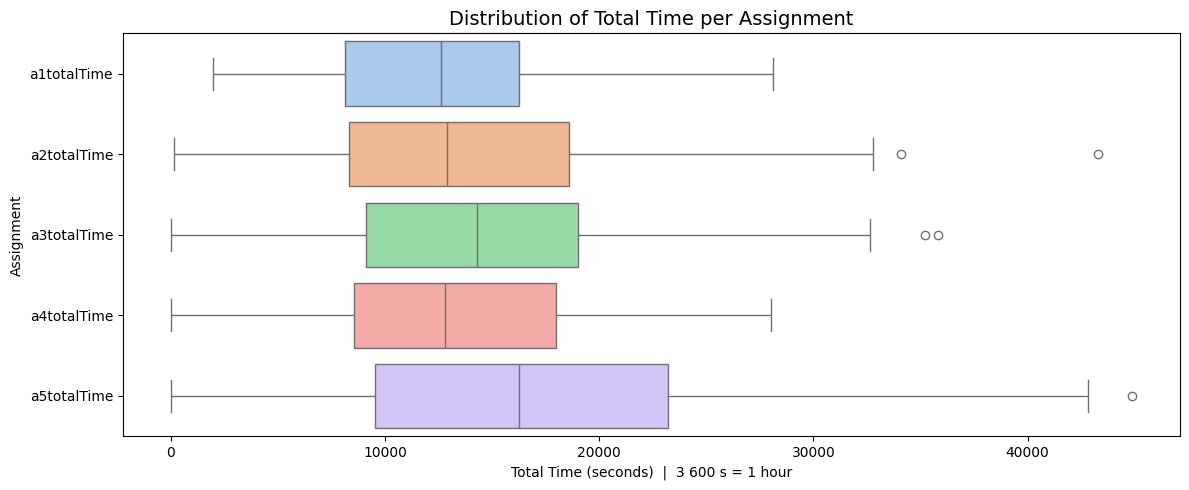

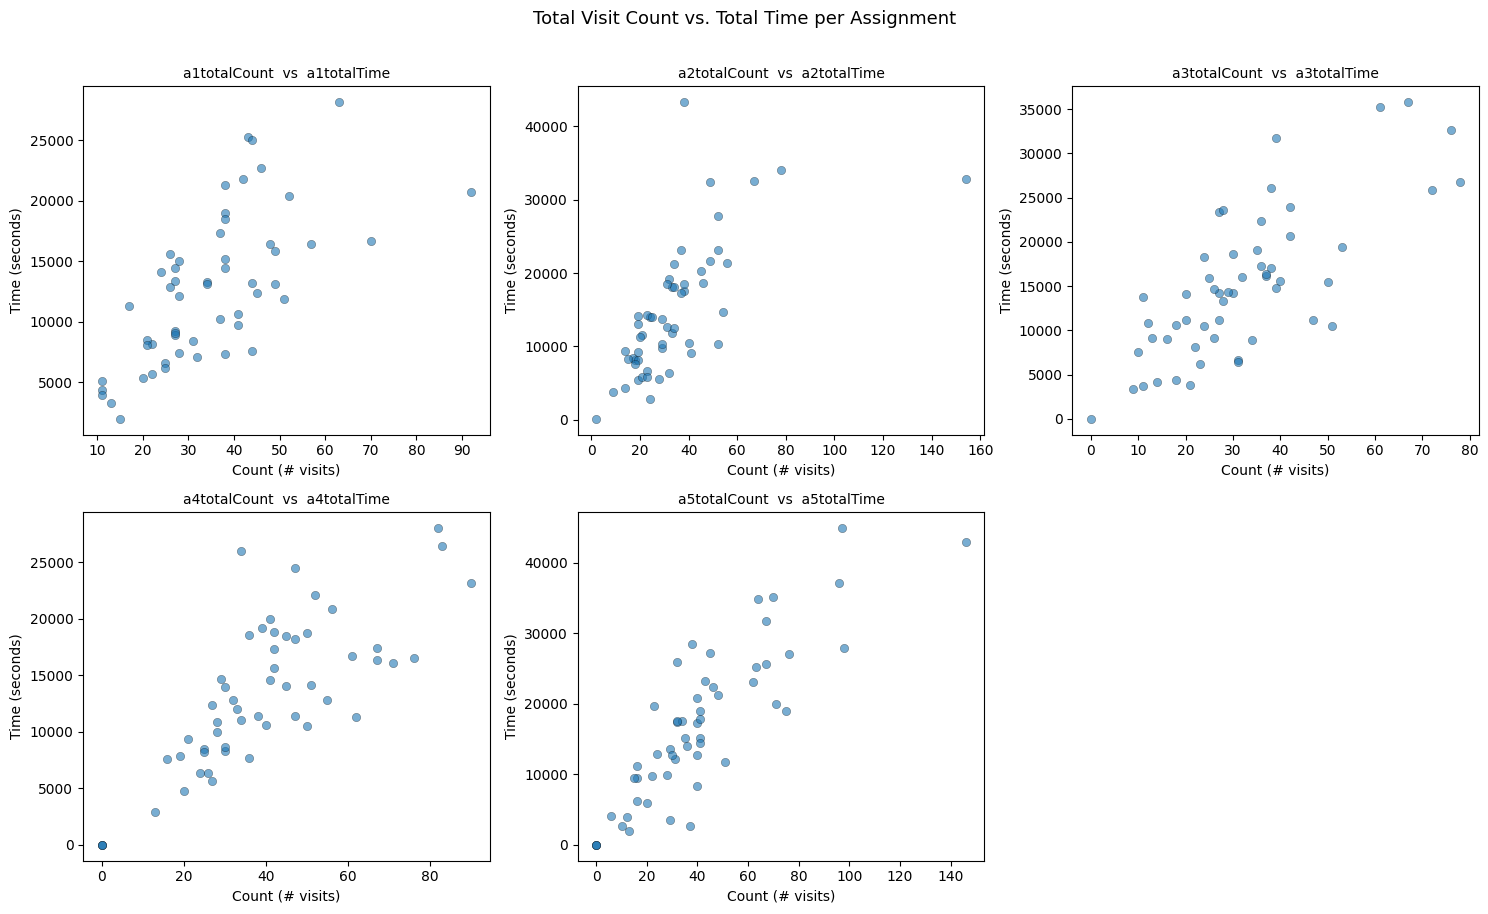

Max total time across all students/assignments: 44873 s = 12.5 hours


In [4]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=assignments.filter(like='totalTime'), orient='h', palette='pastel')
plt.title('Distribution of Total Time per Assignment', fontsize=14)
plt.xlabel('Total Time (seconds)  |  3 600 s = 1 hour')
plt.ylabel('Assignment')
plt.tight_layout()
plt.show()

count_cols = assignments.filter(like='totalCount').columns.tolist()
n = len(count_cols)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(count_cols):
    time_col = col.replace('totalCount', 'totalTime')
    axes[i].scatter(assignments[col], assignments[time_col], alpha=0.6, edgecolors='k', linewidths=0.3)
    axes[i].set_title(f"{col}  vs  {time_col}", fontsize=10)
    axes[i].set_xlabel('Count (# visits)')
    axes[i].set_ylabel('Time (seconds)')

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Total Visit Count vs. Total Time per Assignment', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

max_time = assignments.filter(like='totalTime').max().max()
print(f"Max total time across all students/assignments: {max_time:.0f} s = {max_time/3600:.1f} hours")

### Merge with grades and check correlations

Now that we have our first engineered features, let's see if they actually **predict grades**.
We'll merge the feature DataFrame with the grades and compute Pearson correlations.

> 💡 Pearson correlation ranges from −1 (perfect negative) to +1 (perfect positive).
> A value of 0 means no linear relationship. Correlations around ±0.2–0.4 are already interesting for behavioural data.

In [5]:

grades = pd.merge(grades, assignments, on='userID', how='left')

print(f"Grades DataFrame shape: {grades.shape}")
grades.head()

Grades DataFrame shape: (54, 17)


,userID,A1,A2,A3,A4,A5,FinalScore,a1totalCount,a2totalCount,a3totalCount,a4totalCount,a5totalCount,a1totalTime,a2totalTime,a3totalTime,a4totalTime,a5totalTime
0,100001,93.75,68.75,100.00,76.47,82.05,59.97,38,37,37,61,48,18996.0,23123.0,16144.0,16740.0,21227.0
1,100002,112.50,125.00,100.00,88.24,92.31,77.81,46,49,39,42,64,22696.0,32448.0,31711.0,18822.0,34843.0
2,100003,100.00,125.00,121.43,94.12,93.59,89.88,38,33,37,24,29,21270.0,18153.0,16327.0,6363.0,3510.0
3,100004,116.67,125.00,75.00,52.94,57.69,73.30,41,19,38,28,40,9699.0,5456.0,17095.0,10841.0,12777.0
4,100005,95.83,106.25,82.14,35.29,33.33,56.57,27,52,51,27,51,9231.0,10358.0,10529.0,5690.0,11731.0


In [6]:
correlation_results = {}

for i in range(1, 6):
    grade_col = f'A{i}'
    time_col  = f'a{i}totalTime'

    if grade_col in grades.columns and time_col in grades.columns:
        corr = grades[[grade_col, time_col]].corr().iloc[0, 1]
        correlation_results[grade_col] = round(corr, 3)

print("Correlation between assignment grade and total time on that assignment:")
for k, v in correlation_results.items():
    print(f"  {k} ↔ {k.lower()}totalTime :  r = {v}")

Correlation between assignment grade and total time on that assignment:
  A1 ↔ a1totalTime :  r = 0.351
  A2 ↔ a2totalTime :  r = 0.207
  A3 ↔ a3totalTime :  r = 0.444
  A4 ↔ a4totalTime :  r = 0.551
  A5 ↔ a5totalTime :  r = 0.555


These are decent correlations for a behavioural feature.
A2 is the exception — we'd want to investigate the assignment content to understand why.

Let's also look at the **full correlation matrix** across all grade and feature columns to get a wider picture.

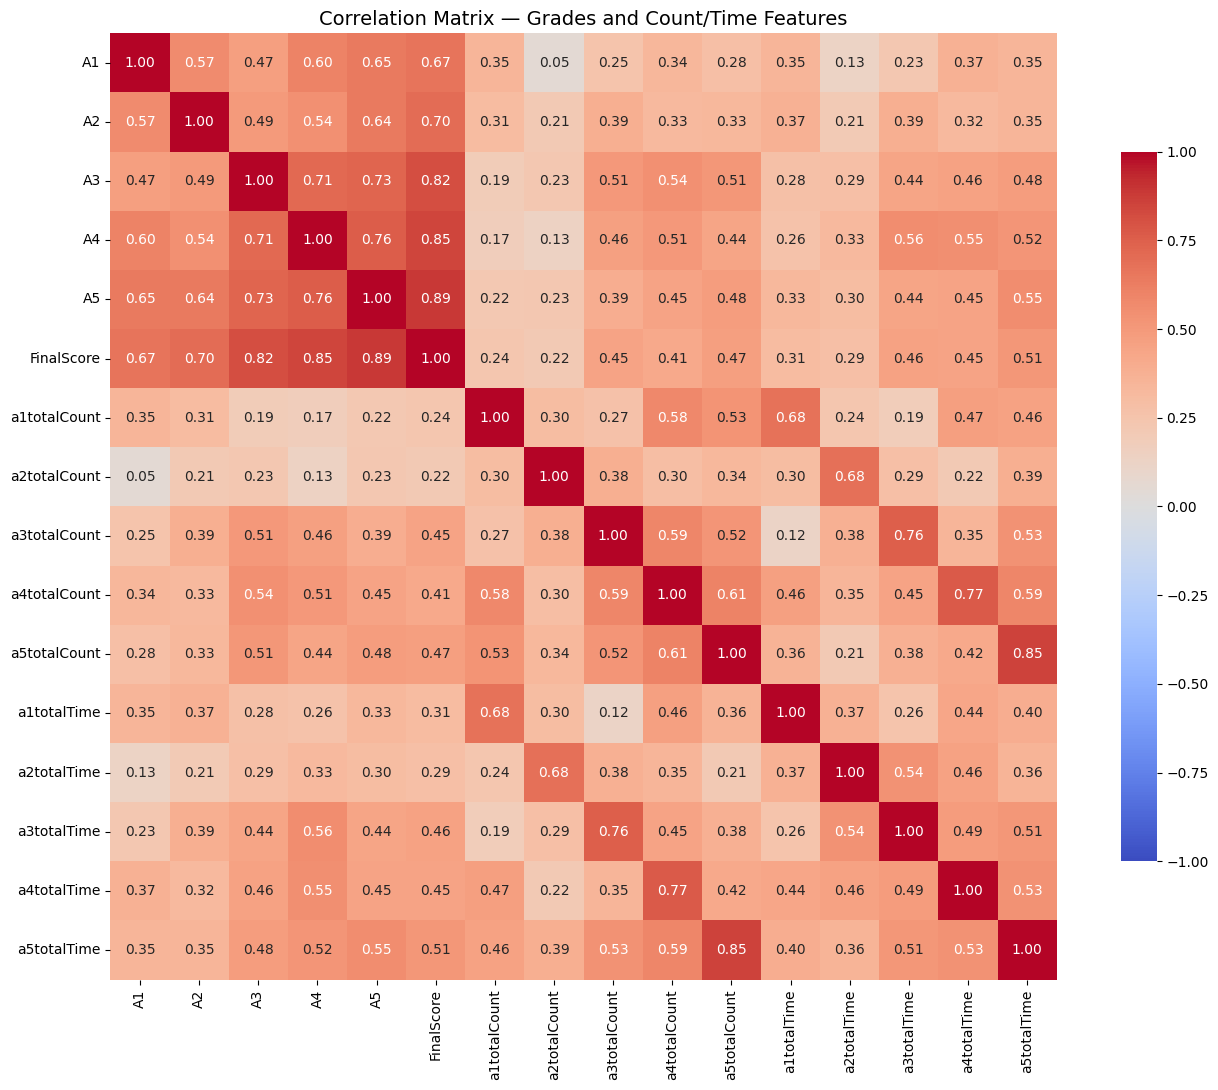

In [7]:
correlation_matrix = grades.drop(columns=['userID']).corr()

plt.figure(figsize=(14, 11))
sns.heatmap(
    correlation_matrix,
    annot=True, fmt=".2f", cmap='coolwarm',
    square=True, cbar_kws={"shrink": .75},
    vmin=-1, vmax=1
)
plt.title('Correlation Matrix — Grades and Count/Time Features', fontsize=14)
plt.tight_layout()
plt.show()

---
## Feature Family 2 — Temporal / Day-Based Features

Counts and time tell us *how much* a student engaged.
But **when** they worked can be equally important:

| Feature | Question answered |
|---|---|
| `firstDay` | How early did they start (days before deadline)? |
| `secondDay` | When did they come back for the second session? |
| `nDays` | Over how many distinct days did they work? |
| `nDaysFinalWeek` | Did they cram everything into the last 7 days? |
| `nDaysAfterDeadline` | Did they access pages after the deadline (late submission risk)? |

> 💡 **Key idea:** A student who starts 14 days before the deadline and works a little each day
> has a very different pattern from one who starts the night before.
> These features give the model a way to capture that difference.

First, we need the **deadline dates** for each assignment.

In [8]:
deadlines = {
    'a1': pd.to_datetime('2026-05-27 23:59:00-07:00'),
    'a2': pd.to_datetime('2026-06-15 23:59:00-07:00'),
    'a3': pd.to_datetime('2026-07-05 23:59:00-07:00'),
    'a4': pd.to_datetime('2026-07-15 23:59:00-07:00'),
    'a5': pd.to_datetime('2026-08-09 23:59:00-07:00')
}

for assignment, deadline in deadlines.items():
    print(assignment, deadline.date())

a1 2026-05-27
a2 2026-06-15
a3 2026-07-05
a4 2026-07-15
a5 2026-08-09


Now we loop over every (student, assignment) group in the log to compute the temporal features.

The key formula is:
```
days_before_deadline = (deadline.date() - access_date).days
```
A positive number means the student accessed the page **before** the deadline.
A negative number means they accessed it **after** — which might indicate late work or reviewing feedback.

In [9]:
log['start_time'] = pd.to_datetime(log['start_time'], utc=True)
log['work_date'] = log['start_time'].dt.date

day_rows = []

for (user, assignment), data in log.groupby(['userID', 'assignment']):
    if assignment not in deadlines:
        continue

    deadline_day = deadlines[assignment].date()
    dates = sorted(data['work_date'].unique())
    days_before = [(deadline_day - d).days for d in dates]

    day_rows.append({
        'userID': user,
        'assignment': assignment,
        'firstDay': days_before[0],
        'secondDay': days_before[1] if len(days_before) > 1 else np.nan,
        'firstSecondGap': days_before[0] - days_before[1] if len(days_before) > 1 else np.nan,
        'nDays': len(dates),
        'nDaysFinalWeek': len([day for day in days_before if 0 <= day <= 7]),
        'nDaysBeforeFinalWeek': len([day for day in days_before if day > 7]),
        'nDaysAfterDeadline': len([day for day in days_before if day < 0])
    })

activity_summary = pd.DataFrame(day_rows)

print("activity_summary shape:", activity_summary.shape)
activity_summary.head(10)

activity_summary shape: (263, 9)


,userID,assignment,firstDay,secondDay,firstSecondGap,nDays,nDaysFinalWeek,nDaysBeforeFinalWeek,nDaysAfterDeadline
0,100001,a1,7,4.0,3.0,7,6,0,1
1,100001,a2,18,12.0,6.0,11,6,4,1
2,100001,a3,10,6.0,4.0,9,5,1,3
3,100001,a4,4,3.0,1.0,9,4,0,5
4,100001,a5,15,14.0,1.0,8,3,4,1
5,100002,a1,16,9.0,7.0,9,6,2,1
6,100002,a2,19,18.0,1.0,14,5,6,3
7,100002,a3,18,15.0,3.0,13,5,6,2
8,100002,a4,6,2.0,4.0,6,4,0,2
9,100002,a5,27,24.0,3.0,14,6,6,2


### Reshaping the data: wide vs. long format

The grade table is wide because each assignment has its own column.  
For the next part, I want one row to represent one student and one assignment.

To do that, I reshape the count, time, and grade columns into long format.  
This makes the merge easier because every table can use the same two keys: `userID` and `assignment`.

In [10]:
count_cols = [f'a{i}totalCount' for i in range(1, 6)]
time_cols = [f'a{i}totalTime' for i in range(1, 6)]
grade_cols = [f'A{i}' for i in range(1, 6)]

counts_long = grades.melt(
    id_vars='userID',
    value_vars=count_cols,
    var_name='assignment',
    value_name='totalCount'
)

counts_long['assignment'] = counts_long['assignment'].str[:2]

times_long = grades.melt(
    id_vars='userID',
    value_vars=time_cols,
    var_name='assignment',
    value_name='totalTime'
)

times_long['assignment'] = times_long['assignment'].str[:2]

grades_long = grades.melt(
    id_vars=['userID', 'FinalScore'],
    value_vars=grade_cols,
    var_name='assignment',
    value_name='grade'
)

grades_long['assignment'] = grades_long['assignment'].str.lower()

activity_totals = pd.merge(grades_long, counts_long, on=['userID', 'assignment'], how='left')
activity_totals = pd.merge(activity_totals, times_long, on=['userID', 'assignment'], how='left')

activity_totals = activity_totals[
    ['userID', 'assignment', 'grade', 'FinalScore', 'totalCount', 'totalTime']
]

print("activity_totals shape:", activity_totals.shape)
activity_totals.head()

activity_totals shape: (270, 6)


,userID,assignment,grade,FinalScore,totalCount,totalTime
0,100001,a1,93.75,59.97,38,18996.0
1,100002,a1,112.50,77.81,46,22696.0
2,100003,a1,100.00,89.88,38,21270.0
3,100004,a1,116.67,73.30,41,9699.0
4,100005,a1,95.83,56.57,27,9231.0


Now I add the temporal features to the long-format table.  
This gives one combined table with grades, totals, and timing features for each student-assignment pair.

In [11]:
grades2 = pd.merge(
    activity_totals,
    activity_summary,
    on=['userID', 'assignment'],
    how='left'
)

print("grades2 shape:", grades2.shape)
grades2.head()

grades2 shape: (270, 13)


,userID,assignment,grade,FinalScore,totalCount,totalTime,firstDay,secondDay,firstSecondGap,nDays,nDaysFinalWeek,nDaysBeforeFinalWeek,nDaysAfterDeadline
0,100001,a1,93.75,59.97,38,18996.0,7.0,4.0,3.0,7.0,6.0,0.0,1.0
1,100002,a1,112.50,77.81,46,22696.0,16.0,9.0,7.0,9.0,6.0,2.0,1.0
2,100003,a1,100.00,89.88,38,21270.0,12.0,6.0,6.0,7.0,6.0,1.0,0.0
3,100004,a1,116.67,73.30,41,9699.0,6.0,1.0,5.0,5.0,3.0,0.0,2.0
4,100005,a1,95.83,56.57,27,9231.0,6.0,5.0,1.0,6.0,5.0,0.0,1.0


## Correlation matrix: all features vs. grades

Now I check whether the engineered features have a relationship with assignment grades.

I calculate the correlation separately for each assignment.  
This is easier to read because A1 features are compared with A1 grades, A2 features with A2 grades, and so on.

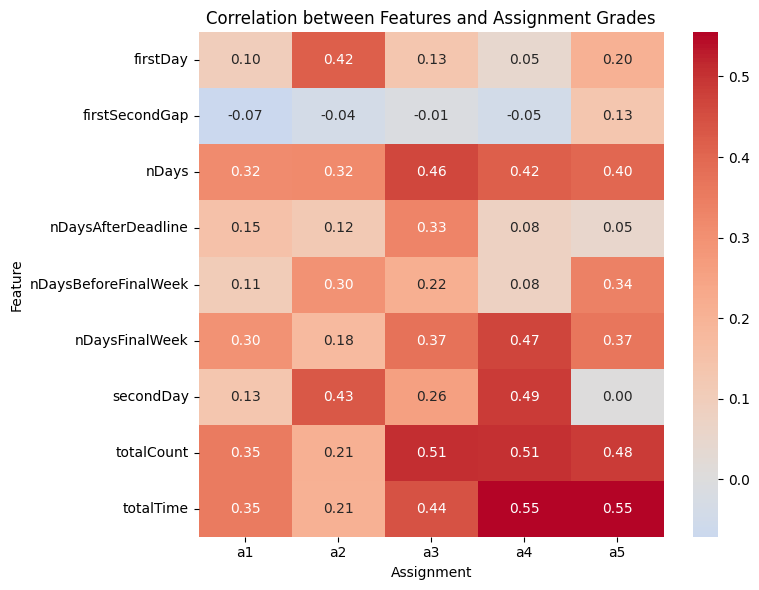

assignment,a1,a2,a3,a4,a5
feature,,,,,
firstDay,0.098,0.419,0.132,0.048,0.204
firstSecondGap,-0.071,-0.038,-0.009,-0.046,0.133
nDays,0.315,0.318,0.462,0.416,0.401
nDaysAfterDeadline,0.150,0.121,0.330,0.081,0.051
nDaysBeforeFinalWeek,0.105,0.297,0.217,0.080,0.340
nDaysFinalWeek,0.297,0.176,0.373,0.471,0.369
secondDay,0.130,0.430,0.258,0.486,0.003
totalCount,0.350,0.211,0.507,0.505,0.484
totalTime,0.351,0.207,0.444,0.551,0.555


In [12]:
feature_cols = [
    'totalCount',
    'totalTime',
    'firstDay',
    'secondDay',
    'firstSecondGap',
    'nDays',
    'nDaysFinalWeek',
    'nDaysBeforeFinalWeek',
    'nDaysAfterDeadline'
]

corr_rows = []

for assignment in ['a1', 'a2', 'a3', 'a4', 'a5']:
    temp = grades2[grades2['assignment'] == assignment]

    for feature in feature_cols:
        corr = temp[['grade', feature]].corr().iloc[0, 1]

        corr_rows.append({
            'assignment': assignment,
            'feature': feature,
            'correlation': corr
        })

corr_table = pd.DataFrame(corr_rows)
corr_heatmap = corr_table.pivot(index='feature', columns='assignment', values='correlation')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_heatmap, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation between Features and Assignment Grades')
plt.xlabel('Assignment')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

corr_heatmap.round(3)

Some features are redundant.  
For example, `firstSecondGap` is made from `firstDay` and `secondDay`, so it does not add completely new information.

I remove the redundant columns before adding the ratio feature.

In [13]:
drop_cols = ['firstSecondGap', 'nDaysBeforeFinalWeek']

grades2 = grades2.drop(columns=drop_cols)

print("Columns after dropping redundant features:")
print(grades2.columns.tolist())
grades2.head()

Columns after dropping redundant features:
['userID', 'assignment', 'grade', 'FinalScore', 'totalCount', 'totalTime', 'firstDay', 'secondDay', 'nDays', 'nDaysFinalWeek', 'nDaysAfterDeadline']


,userID,assignment,grade,FinalScore,totalCount,totalTime,firstDay,secondDay,nDays,nDaysFinalWeek,nDaysAfterDeadline
0,100001,a1,93.75,59.97,38,18996.0,7.0,4.0,7.0,6.0,1.0
1,100002,a1,112.50,77.81,46,22696.0,16.0,9.0,9.0,6.0,1.0
2,100003,a1,100.00,89.88,38,21270.0,12.0,6.0,7.0,6.0,0.0
3,100004,a1,116.67,73.30,41,9699.0,6.0,1.0,5.0,3.0,2.0
4,100005,a1,95.83,56.57,27,9231.0,6.0,5.0,6.0,5.0,1.0


---
## Feature Family 3 — Ratios

Counts and totals show how much a student used Canvas.  
A ratio shows how that time was divided.

For this feature, I calculate:

`detailRatio = detailTime / totalTime`

This tells me the share of assignment time that was spent on the detail-specification page.  
A higher ratio may mean the student spent more of their time reading the actual assignment instructions.

In [14]:
detail_pages = log[log['url'].str.contains('detail-specification', na=False)]

detail_time = (
    detail_pages
    .groupby(['userID', 'assignment'])['view_length']
    .sum()
    .reset_index()
)

detail_time = detail_time.rename(columns={'view_length': 'detailTime'})

print("Detail page rows:", len(detail_pages))
print("detail_time shape:", detail_time.shape)
detail_time.head()

Detail page rows: 2303
detail_time shape: (262, 3)


,userID,assignment,detailTime
0,100001,a1,8745.0
1,100001,a2,15355.0
2,100001,a3,12559.0
3,100001,a4,9388.0
4,100001,a5,7512.0


count    270.000
mean       0.518
std        0.249
min        0.000
25%        0.352
50%        0.537
75%        0.717
max        0.992
Name: detailRatio, dtype: float64


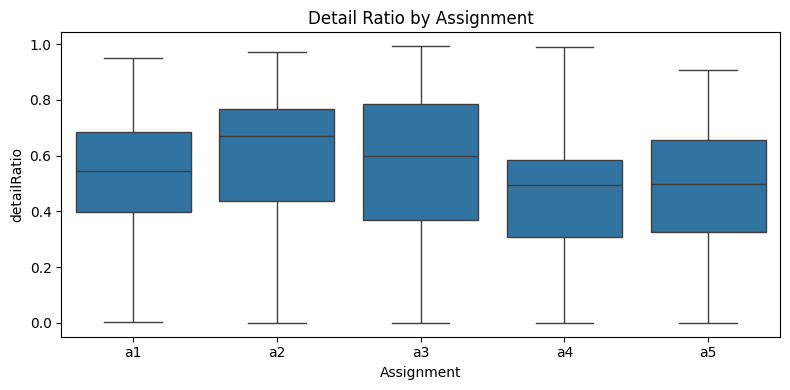

,userID,assignment,grade,FinalScore,totalCount,totalTime,firstDay,secondDay,nDays,nDaysFinalWeek,nDaysAfterDeadline,detailTime,detailRatio
0,100001,a1,93.75,59.97,38,18996.0,7.0,4.0,7.0,6.0,1.0,8745.0,0.460360
1,100002,a1,112.50,77.81,46,22696.0,16.0,9.0,9.0,6.0,1.0,15920.0,0.701445
2,100003,a1,100.00,89.88,38,21270.0,12.0,6.0,7.0,6.0,0.0,11732.0,0.551575
3,100004,a1,116.67,73.30,41,9699.0,6.0,1.0,5.0,3.0,2.0,4481.0,0.462006
4,100005,a1,95.83,56.57,27,9231.0,6.0,5.0,6.0,5.0,1.0,6657.0,0.721157


In [15]:
grades2 = pd.merge(
    grades2,
    detail_time,
    on=['userID', 'assignment'],
    how='left'
)

grades2['detailTime'] = grades2['detailTime'].fillna(0)

grades2['detailRatio'] = grades2['detailTime'] / grades2['totalTime']
grades2['detailRatio'] = grades2['detailRatio'].replace([np.inf, -np.inf], np.nan)
grades2['detailRatio'] = grades2['detailRatio'].fillna(0)

print(grades2['detailRatio'].describe().round(3))

plt.figure(figsize=(8, 4))
sns.boxplot(data=grades2, x='assignment', y='detailRatio', order=['a1', 'a2', 'a3', 'a4', 'a5'])
plt.title('Detail Ratio by Assignment')
plt.xlabel('Assignment')
plt.ylabel('detailRatio')
plt.tight_layout()
plt.show()

grades2.head()

Finally, I check whether `detailRatio` has a relationship with assignment grades.

In [16]:
ratio_results = []

for assignment in ['a1', 'a2', 'a3', 'a4', 'a5']:
    temp = grades2[grades2['assignment'] == assignment]
    corr = temp[['grade', 'detailRatio']].corr().iloc[0, 1]

    ratio_results.append({
        'assignment': assignment,
        'detailRatio_correlation': corr
    })

ratio_corr = pd.DataFrame(ratio_results)
ratio_corr['detailRatio_correlation'] = ratio_corr['detailRatio_correlation'].round(3)

ratio_corr

,assignment,detailRatio_correlation
0,a1,0.116
1,a2,0.369
2,a3,0.145
3,a4,0.121
4,a5,0.315


---
## Putting it all together — Linear Regression

Now that we have three families of features, let's fit a simple **multiple linear regression** model
to predict each assignment grade.

This is not the main focus of today's lecture, but it gives us a concrete way to evaluate
whether our feature engineering paid off:
- **R²** — what percentage of grade variance do our features explain?
- **RMSE** — on average, how many grade points is our prediction off by?
- **Coefficients** — which features are most influential?

> ⚠️ **Important:** We are fitting on the full dataset (no train/test split) just to get a feel for the features.
> In a proper study you would use cross-validation (see the `LeaveOneOut` import below).

Let's run a separate model for each assignment.

Note: `totalTime` is in **seconds**, which is a very large number compared to a grade (0–100).
The coefficient printed will look like 0.000, not because time has no effect,
but because one extra *second* barely moves the grade.
We'll convert to hours to make the coefficient interpretable.

### Interpreting the model

**How to read the coefficients:**
- A coefficient of `+2.5` on `firstDay` means: *for every extra day earlier a student started, the model predicts 2.5 more grade points* (all else being equal).
- A coefficient of `−5.6` on `nDaysAfterDeadline` means: *each day a student accessed pages after the deadline is associated with −5.6 grade points* — possibly indicating late or incomplete submissions.

**Why R² is modest (~0.25):**
> This model has no information about the student's background or programming skill.
> A strong programmer might spend very little time on Canvas yet score 95.
> A struggling student might spend many hours yet score 40.
> Our behavioural features alone can explain about 25% of the variance — which is actually meaningful given what we're working with!

---
## Summary: What we did today

| Step | Action | Pandas / sklearn tool |
|---|---|---|
| 1 | Counted page views per student per assignment | `groupby().size().unstack()` |
| 2 | Summed time spent per student per assignment | `groupby()[col].sum().unstack()` |
| 3 | Computed temporal features (days before deadline) | Manual loop + `pd.DataFrame` |
| 4 | Reshaped data from wide to long | `pd.melt()` + `pd.merge()` |
| 5 | Computed ratio feature (detail page proportion) | Column arithmetic |
| 6 | Evaluated all features with correlation heatmap | `.corr()` + `sns.heatmap()` |
| 7 | Dropped redundant/collinear features | `df.drop(columns=[...])` |
| 8 | Fit linear regression to assess predictive power | `sklearn.LinearRegression` |

**Key takeaways:**
- Feature engineering turns raw events into model-ready inputs using domain knowledge.
- Always **visualise and check correlations** before using features in a model.
- **Redundant features** (those that can be derived from others) should be removed to avoid collinearity.
- **Scale matters**: a feature in seconds and a feature in counts are on very different scales — consider normalising or converting units before interpreting coefficients.